In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)

BAND_EDGE = 49  # last in-band bin
REGROWTH_START = 50  # first out-of-band bin
REGROWTH_END = 83  # highest confirmed separability bin
ANALYSIS_END = 150  # outer analysis boundary
MAIN_LOBE_START = 5  # for ratio features
MAIN_LOBE_END = 49  # last main-lobe bin before band edge
N_BINS = 800
LABEL_COL = "nonlinear"
TEST_SIZE = 0.2
N_SPLITS = 5
RANDOM_STATE = 42
CSV_PATH = os.path.join(os.path.dirname(os.getcwd()), "data", "data.csv")

np.random.seed(RANDOM_STATE)

Section 0 initialized: imports loaded, constants defined, CSV path = c:\Users\oaraf\Desktop\Honors Thesis\data\data.csv


Class distribution (0=linear, 1=nonlinear):
nonlinear
0    5000
1    5000
Name: count, dtype: int64
Confirmed split -> linear: 5000, nonlinear: 5000


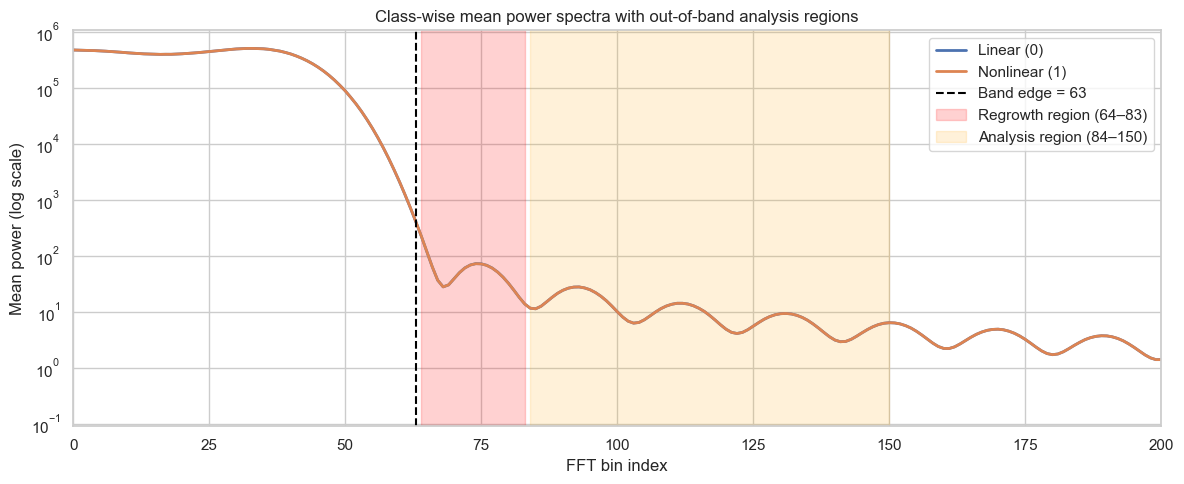

Validation complete: downstream ML will use only bins 64–150 (out-of-band).


In [ ]:
# load and validate data
df = pd.read_csv(CSV_PATH)

assert df.shape[1] == N_BINS + 1, f"Expected {N_BINS + 1} columns, found {df.shape[1]}."
assert LABEL_COL in df.columns, f"Missing label column: {LABEL_COL}"

# extract bins by position to avoid name dependencies
X_bins = df.iloc[:, :N_BINS].to_numpy(dtype=float)
y = df[LABEL_COL].to_numpy(dtype=int)

assert X_bins.shape[1] == N_BINS, "Feature extraction must include exactly 800 FFT bins."
assert np.isin(y, [0, 1]).all(), "Labels must be binary: 0 (linear), 1 (nonlinear)."

class_counts = pd.Series(y, name=LABEL_COL).value_counts().sort_index()
print("Class distribution (0=linear, 1=nonlinear):")
print(class_counts)

# plot class-wise mean spectrum
bins = np.arange(N_BINS)
mean_linear = X_bins[y == 0].mean(axis=0)
mean_nonlinear = X_bins[y == 1].mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(bins, mean_linear, label="Linear (0)", linewidth=2)
plt.plot(bins, mean_nonlinear, label="Nonlinear (1)", linewidth=2)
plt.yscale("log")
plt.axvline(BAND_EDGE, color="black", linestyle="--", linewidth=1.5, label=f"Band edge = {BAND_EDGE}")
plt.axvspan(REGROWTH_START, REGROWTH_END, color="red", alpha=0.18, label="Regrowth region (64-83)")
plt.axvspan(REGROWTH_END + 1, ANALYSIS_END, color="orange", alpha=0.15, label="Analysis region (84-150)")
plt.xlim(0, 200)
plt.xlabel("FFT bin index")
plt.ylabel("Mean power (log scale)")
plt.title("Class-wise mean power spectra with out-of-band analysis regions")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print("Validation complete: downstream ML uses bins 64-150 only.")

In [ ]:
# compute engineered out-of-band features
analysis_slice = slice(REGROWTH_START, ANALYSIS_END + 1)
core_slice = slice(REGROWTH_START, REGROWTH_END + 1)
main_lobe_slice = slice(MAIN_LOBE_START, MAIN_LOBE_END + 1)

# extract analysis regions used by all engineered features
analysis_vals = X_bins[:, analysis_slice]
core_vals = X_bins[:, core_slice]
main_lobe_vals = X_bins[:, main_lobe_slice]
analysis_bin_idx = np.arange(REGROWTH_START, ANALYSIS_END + 1)

# feature 1: regrowth power (core energy)
regrowth_power = core_vals.sum(axis=1)

# feature 2: spectral slope across out-of-band bins
spectral_slope = np.array([np.polyfit(analysis_bin_idx, row, 1)[0] for row in analysis_vals])

# feature 3: spectral entropy (distribution spread)
p = analysis_vals / (analysis_vals.sum(axis=1, keepdims=True) + 1e-10)
spectral_entropy = -np.sum(p * np.log(p + 1e-10), axis=1)

# feature 4: spectral flatness (tonal vs noise-like)
spectral_flatness = np.exp(np.mean(np.log(analysis_vals + 1e-10), axis=1)) / (analysis_vals.mean(axis=1) + 1e-10)

# feature 5: acpr in db (adjacent-to-main power ratio)
acpr_db = 10.0 * np.log10(np.clip(core_vals.sum(axis=1) / (main_lobe_vals.sum(axis=1) + 1e-10), 1e-10, None))

# feature 6: spectral kurtosis (peakiness)
mean_analysis = analysis_vals.mean(axis=1, keepdims=True)
spectral_kurtosis = np.mean((analysis_vals - mean_analysis) ** 4, axis=1) / (analysis_vals.std(axis=1) ** 4 + 1e-10)

# assemble engineered feature table used downstream
features_df = pd.DataFrame({
    "regrowth_power": regrowth_power,
    "spectral_slope": spectral_slope,
    "spectral_entropy": spectral_entropy,
    "spectral_flatness": spectral_flatness,
    "acpr_db": acpr_db,
    "spectral_kurtosis": spectral_kurtosis,
})

print("Engineered feature matrix shape:", features_df.shape)
print("\nMean feature value by class (0=linear, 1=nonlinear):")
print(features_df.assign(nonlinear=y).groupby("nonlinear").mean())

# find class separation strength for each engineered feature
cohens_d = {}
for feature in features_df.columns:
    g0 = features_df.loc[y == 0, feature].to_numpy()
    g1 = features_df.loc[y == 1, feature].to_numpy()
    pooled_std = np.sqrt((np.var(g0, ddof=1) + np.var(g1, ddof=1)) / 2.0) + 1e-10
    cohens_d[feature] = np.abs(np.mean(g1) - np.mean(g0)) / pooled_std

print("\nCohen's d effect size by feature:")
for feature, value in cohens_d.items():
    print(f"{feature}: {value:.4f}")

cohens_d_series = pd.Series(cohens_d).sort_values(ascending=False)

Engineered feature matrix shape: (10000, 6)

Mean feature value by class (0=linear, 1=nonlinear):
           regrowth_power  spectral_slope  spectral_entropy  \
nonlinear                                                     
0             1174.779524       -0.756848          3.897742   
1             1174.520175       -0.756995          3.897030   

           spectral_flatness    acpr_db  spectral_kurtosis  
nonlinear                                                   
0                   0.594362 -41.902436          24.504303  
1                   0.594301 -41.902762          24.743475  

Cohen's d effect size by feature:
regrowth_power    : 0.0047
spectral_slope    : 0.0040
spectral_entropy  : 0.0226
spectral_flatness : 0.0038
acpr_db           : 0.0016
spectral_kurtosis : 0.0562


In [ ]:
features_array = features_df.to_numpy(dtype=float)

# build feature sets for raw, engineered, and hybrid representations
feature_sets = {
    "A: Raw Bins 64-150": X_bins[:, REGROWTH_START:ANALYSIS_END + 1],
    "B: Engineered Only": features_array,
    "C: Raw + Engineered": np.hstack([X_bins[:, REGROWTH_START:ANALYSIS_END + 1], features_array]),
    "D: Core Bins 64-83": X_bins[:, REGROWTH_START:REGROWTH_END + 1],
}

for name, X in feature_sets.items():
    print(f"{name:25s} -> {X.shape}")

A: Raw Bins 64-150        -> (10000, 87)
B: Engineered Only        -> (10000, 6)
C: Raw + Engineered       -> (10000, 93)
D: Core Bins 64-83        -> (10000, 20)


In [ ]:
# define model estimators and wrap each with scaling
estimators = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(n_neighbors=11),
}
models = {
    name: Pipeline([("scaler", StandardScaler()), ("model", estimator)])
    for name, estimator in estimators.items()
}

# standardize score extraction for auc and threshold search
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X).astype(float)

# run stratified cv and keep a held-out test split for roc plotting
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
results = []
split_artifacts = {}

for feature_set_name, X in feature_sets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    split_artifacts[feature_set_name] = {"X_test": X_test, "y_test": y_test, "trained_models": {}}

    for model_name, model_pipeline in models.items():
        # collect fold metrics for one model-feature pairing
        fold_metrics = {k: [] for k in ["acc", "prec", "rec", "f1", "auc", "opt_acc", "opt_f1"]}

        for train_idx, val_idx in skf.split(X, y):
            # train on fold train split and evaluate on fold validation split
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            fold_model = clone(model_pipeline).fit(X_tr, y_tr)
            y_pred = fold_model.predict(X_val)
            y_score = get_scores(fold_model, X_val, y_pred)

            # optimize decision threshold by validation accuracy
            thresholds = roc_curve(y_val, y_score)[2]
            accs = [accuracy_score(y_val, (y_score >= t).astype(int)) for t in thresholds]
            best_t = thresholds[int(np.argmax(accs))]
            y_pred_opt = (y_score >= best_t).astype(int)

            # store fold-level default-threshold and optimized-threshold metrics
            fold_metrics["acc"].append(accuracy_score(y_val, y_pred))
            fold_metrics["prec"].append(precision_score(y_val, y_pred, zero_division=0))
            fold_metrics["rec"].append(recall_score(y_val, y_pred, zero_division=0))
            fold_metrics["f1"].append(f1_score(y_val, y_pred, zero_division=0))
            fold_metrics["auc"].append(roc_auc_score(y_val, y_score))
            fold_metrics["opt_acc"].append(accuracy_score(y_val, y_pred_opt))
            fold_metrics["opt_f1"].append(f1_score(y_val, y_pred_opt, zero_division=0))

        # summarize folds into one row per model-feature pairing
        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "accuracy_mean": np.mean(fold_metrics["acc"]),
            "accuracy_std": np.std(fold_metrics["acc"]),
            "precision_mean": np.mean(fold_metrics["prec"]),
            "precision_std": np.std(fold_metrics["prec"]),
            "recall_mean": np.mean(fold_metrics["rec"]),
            "recall_std": np.std(fold_metrics["rec"]),
            "f1_mean": np.mean(fold_metrics["f1"]),
            "f1_std": np.std(fold_metrics["f1"]),
            "auc_mean": np.mean(fold_metrics["auc"]),
            "auc_std": np.std(fold_metrics["auc"]),
            "opt_accuracy_mean": np.mean(fold_metrics["opt_acc"]),
            "opt_accuracy_std": np.std(fold_metrics["opt_acc"]),
            "opt_f1_mean": np.mean(fold_metrics["opt_f1"]),
            "opt_f1_std": np.std(fold_metrics["opt_f1"]),
        })

        # fit on held-out train split and save model for unseen-test roc curves
        split_artifacts[feature_set_name]["trained_models"][model_name] = clone(model_pipeline).fit(X_train, y_train)

results_df = pd.DataFrame(results).sort_values("accuracy_mean", ascending=False).reset_index(drop=True)
print("Cross-validation results (sorted by accuracy_mean):")
display(results_df)

Training Logistic Regression on A: Raw Bins 64-150...
Training SVM on A: Raw Bins 64-150...
Training Random Forest on A: Raw Bins 64-150...
Training Gradient Boosting on A: Raw Bins 64-150...
Training KNN on A: Raw Bins 64-150...
Training Logistic Regression on B: Engineered Only...
Training SVM on B: Engineered Only...
Training Random Forest on B: Engineered Only...
Training Gradient Boosting on B: Engineered Only...
Training KNN on B: Engineered Only...
Training Logistic Regression on C: Raw + Engineered...
Training SVM on C: Raw + Engineered...
Training Random Forest on C: Raw + Engineered...
Training Gradient Boosting on C: Raw + Engineered...
Training KNN on C: Raw + Engineered...
Training Logistic Regression on D: Core Bins 64-83...
Training SVM on D: Core Bins 64-83...
Training Random Forest on D: Core Bins 64-83...
Training Gradient Boosting on D: Core Bins 64-83...
Training KNN on D: Core Bins 64-83...

Cross-validation results (sorted by accuracy_mean):


,feature_set,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auc_mean,auc_std,opt_accuracy_mean,opt_accuracy_std,opt_f1_mean,opt_f1_std
0,B: Engineered Only,Logistic Regression,0.5157,0.013052,0.515850,0.012892,0.5134,0.017048,0.514525,0.013411,0.524247,0.013012,0.5255,0.006950,0.497559,0.073957
1,D: Core Bins 64-83,Logistic Regression,0.5116,0.009754,0.511689,0.010072,0.5130,0.013506,0.512242,0.009437,0.514059,0.009570,0.5196,0.006200,0.490177,0.134355
2,B: Engineered Only,SVM,0.4827,0.004389,0.482255,0.004820,0.4760,0.045743,0.478095,0.025055,0.521692,0.006047,0.5230,0.004301,0.536202,0.120632
3,C: Raw + Engineered,Logistic Regression,0.4779,0.005171,0.478059,0.005404,0.4826,0.017772,0.480194,0.010514,0.469849,0.008982,0.5027,0.001327,0.194892,0.247924
4,A: Raw Bins 64-150,Logistic Regression,0.4764,0.008083,0.476519,0.007977,0.4776,0.014094,0.476956,0.009036,0.470426,0.008401,0.5021,0.001594,0.197177,0.248868
5,B: Engineered Only,Gradient Boosting,0.4425,0.013657,0.440189,0.012763,0.4224,0.033272,0.430484,0.019989,0.414591,0.013050,0.5000,0.000000,0.000000,0.000000
6,D: Core Bins 64-83,Gradient Boosting,0.3887,0.005946,0.389856,0.005869,0.3944,0.019190,0.391948,0.011850,0.341949,0.010131,0.5000,0.000000,0.000000,0.000000
7,D: Core Bins 64-83,SVM,0.3466,0.003583,0.347956,0.009541,0.3526,0.027601,0.350021,0.018333,0.714538,0.003724,0.6580,0.004147,0.657920,0.019629
8,B: Engineered Only,KNN,0.3294,0.005481,0.330133,0.007122,0.3318,0.011565,0.330944,0.009199,0.289413,0.005356,0.5002,0.000400,0.000798,0.001597
9,D: Core Bins 64-83,KNN,0.3180,0.004550,0.320623,0.004399,0.3254,0.008868,0.322965,0.006251,0.280120,0.004340,0.5000,0.000000,0.000000,0.000000


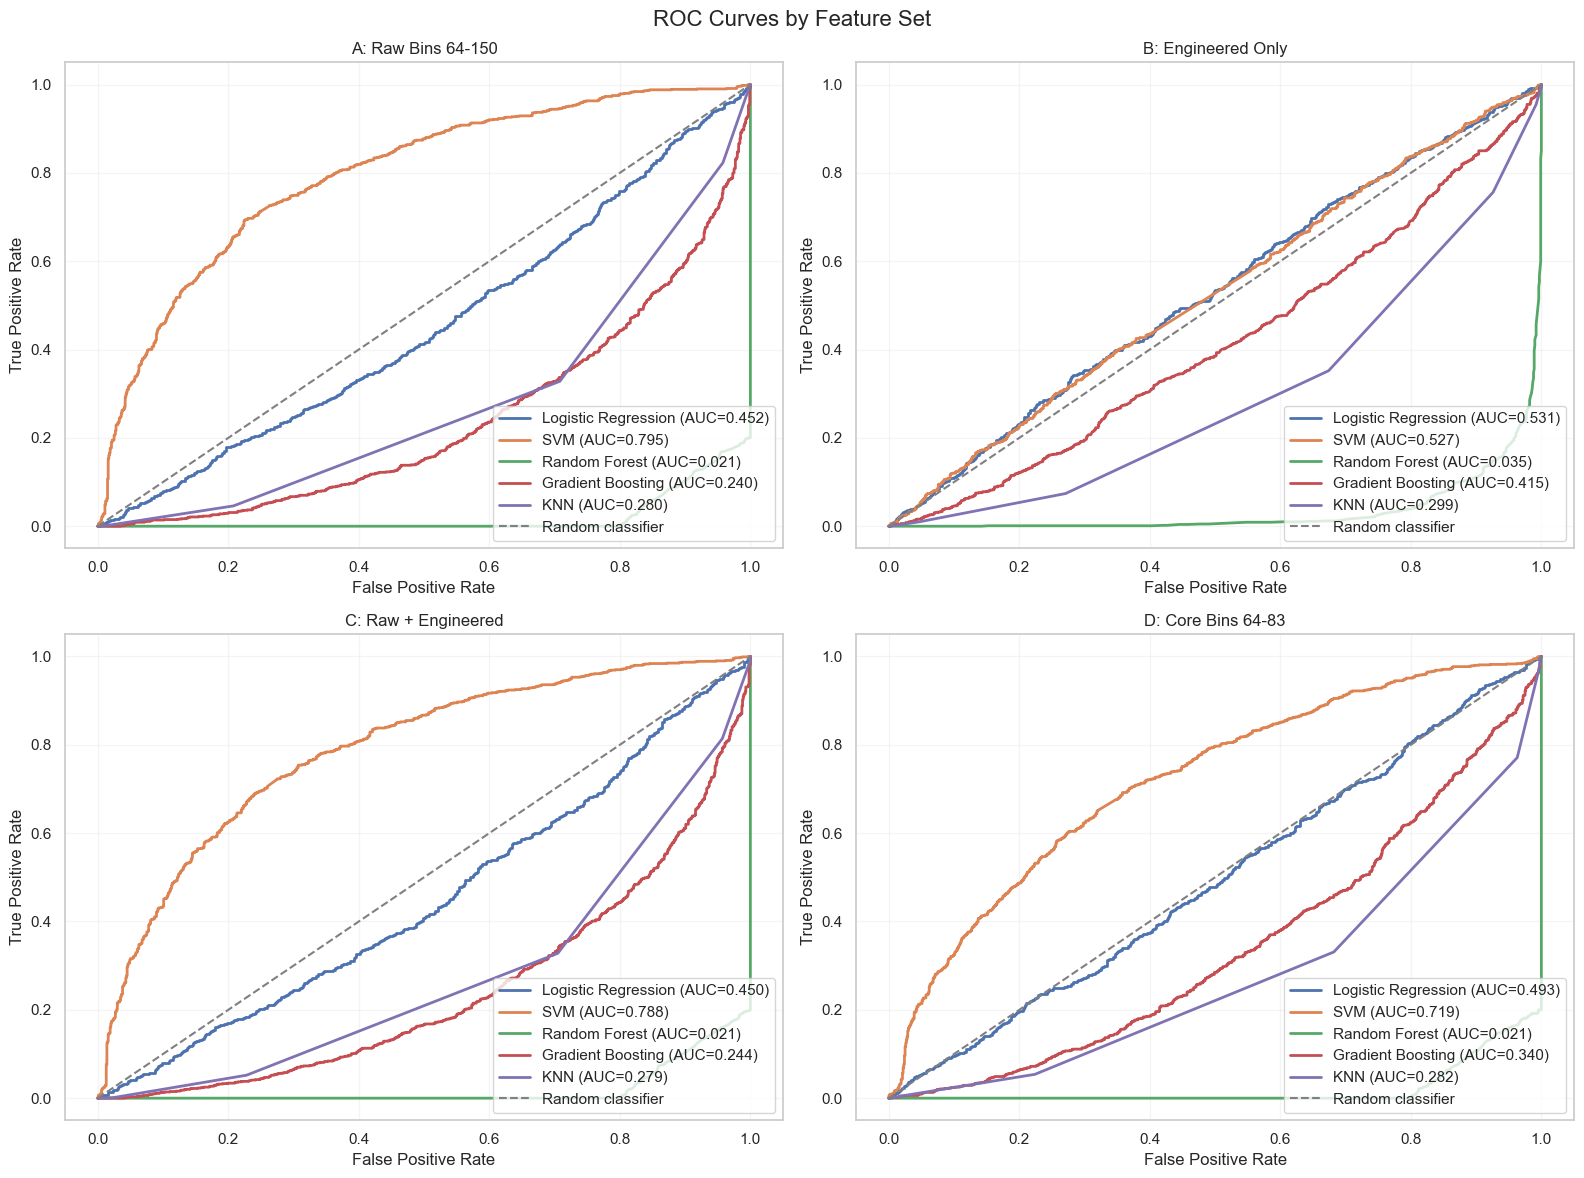

In [ ]:
# plot roc curves by feature set on held-out splits
model_order = list(models.keys())
feature_order = list(feature_sets.keys())

# create one subplot per feature representation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, feature_set_name in zip(axes, feature_order):
    # evaluate all models on the same held-out test split for this feature set
    artifact = split_artifacts[feature_set_name]
    X_test, y_test = artifact["X_test"], artifact["y_test"]

    # draw one roc curve per trained model
    for model_name in model_order:
        fitted_model = artifact["trained_models"][model_name]
        y_pred = fitted_model.predict(X_test)
        y_score = get_scores(fitted_model, X_test, y_pred)
        if hasattr(fitted_model, "decision_function") and not hasattr(fitted_model, "predict_proba"):
            y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-10)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc_val = roc_auc_score(y_test, y_score)
        ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={auc_val:.3f})")

    # add random baseline and axis formatting
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Random classifier")
    ax.set_title(feature_set_name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower right")

fig.suptitle("ROC Curves by Feature Set", fontsize=16)
plt.tight_layout()
plt.show()